In [ ]:
%pip install -q medmnist lime shap scikit-image tqdm opencv-python
!git clone https://github.com/Data-Science-Group-Attoworld/explainable_dl_for_unstructured_data.git
%cd /content/explainable_dl_for_unstructured_data/computer_vision_explainability

# Computer Vision Explainability Tutorial: Skin Lesion Classification with MedMNIST

In this practical session, we will work with a medical image classification task using the **DermaMNIST** dataset from MedMNIST. The goal is to train and interpret a convolutional neural network that classifies dermoscopic skin lesion images into different diagnostic categories.

We will use a **ResNet-18** model for image classification and then apply several explainable AI methods to understand which image regions influence the model's predictions.

## What we will do in this notebook

1. **Load the DermaMNIST dataset**

   We will load dermoscopic skin lesion images and their corresponding class labels.  
   The dataset contains multiple diagnostic categories, including melanoma, melanocytic nevi, basal cell carcinoma, dermatofibroma, vascular lesions, and keratosis-like lesions.

2. **Prepare the data for deep learning**

   The images will be transformed into PyTorch tensors, normalized, and organized into training, validation, and test data loaders.

3. **Train or load a ResNet-18 classifier**

   We will use a ResNet-18 architecture adapted to the number of DermaMNIST classes.  
   ResNet-18 is based on residual blocks, where each block learns a transformation and adds back its own input through a shortcut connection.

4. **Evaluate the model**

   After training, we will calculate predictions on the test set and inspect whether the model correctly classifies selected examples.

5. **Explain predictions with LIME**

   LIME divides the image into interpretable regions, called superpixels, and tests how removing or perturbing these regions changes the model prediction.  
   This helps identify which parts of the image support a given class prediction.

6. **Explain predictions with Grad-CAM**

   Grad-CAM uses gradients from the neural network to produce a heatmap showing which spatial regions were most relevant for a selected class.  
   We will use Grad-CAM in two ways:

   - compare melanoma and non-melanoma examples;
   - explain the same image for several different target classes.

7. **Explain predictions with SHAP**

   SHAP estimates how different image regions contribute positively or negatively to the model output.  
   We will visualize SHAP explanations for the top predicted classes of selected test images.

## Main learning goal

By the end of this notebook, we should understand not only **what** the model predicts, but also **which image regions contributed to the prediction** according to different explainability methods.

This is especially important in medical AI, where model performance alone is not enough. We also need to inspect whether the model appears to focus on clinically meaningful image regions or whether it may rely on irrelevant visual patterns.

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import transforms, models

import medmnist

from lime import lime_image
from skimage.segmentation import slic, mark_boundaries

import shap

import textwrap

import cv2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Understanding the DermaMNIST Dataset

DermaMNIST is based on the HAM10000 dermoscopy dataset.  
It contains images of pigmented skin lesions and a label for each image.

The task is a **multi-class image classification problem**:

* The input is a skin lesion image.
* The output is one of seven diagnostic classes.
* The model learns visual patterns that help separate these classes.

For the explainability part, this is useful because we can ask:

> Which image regions were important for this predicted diagnosis?

In [49]:
# Dataset configuration
data_flag = "dermamnist"

info = medmnist.INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

n_channels = info["n_channels"]
n_classes = len(info["label"])

class_names = [info["label"][str(i)] for i in range(n_classes)]

print(f"Dataset: {data_flag}")
print(f"Number of channels: {n_channels}")
print(f"Number of classes: {n_classes}")
print("\nClass labels:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Dataset: dermamnist
Number of channels: 3
Number of classes: 7

Class labels:
0: actinic keratoses and intraepithelial carcinoma
1: basal cell carcinoma
2: benign keratosis-like lesions
3: dermatofibroma
4: melanoma
5: melanocytic nevi
6: vascular lesions


## Loading the Data Once

We normalize the images before sending them into the neural network.

In [50]:
mean = 0.5
std = 0.5

batch_size = 128
image_size = 64

normalize_mean = [mean] * n_channels
normalize_std = [std] * n_channels

data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=normalize_mean, std=normalize_std),
    ]
)

train_dataset = DataClass(
    split="train", transform=data_transform, size=image_size, download=True
)
val_dataset = DataClass(
    split="val", transform=data_transform, size=image_size, download=True
)
test_dataset = DataClass(
    split="test", transform=data_transform, size=image_size, download=True
)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 7007
Validation samples: 1003
Test samples: 2005


## Helper Functions for Plotting

The model sees normalized tensors, but for visualization we want images in the original `[0, 1]` range.

These helper functions are used repeatedly in the validation and explanation sections.

In [51]:
def wrap_class_name(class_name, width=18):
    """
    Break long class names into multiple lines for cleaner plot titles.
    """
    import textwrap

    return "\n".join(textwrap.wrap(str(class_name), width=width))


def unnormalize_image_tensor(image, mean=0.5, std=0.5):
    """
    Convert a normalized image tensor [C, H, W] back to the [0, 1] range.
    """
    image = image.detach().cpu()
    image = image * std + mean
    image = image.clamp(0, 1)
    return image


def tensor_to_numpy_image(image, mean=0.5, std=0.5):
    """
    Convert a normalized image tensor [C, H, W] to a NumPy image [H, W, C].
    """
    image = unnormalize_image_tensor(image, mean=mean, std=std)
    return image.permute(1, 2, 0).numpy()


def rgb2gray(rgb):
    """
    Convert an RGB image [H, W, 3] to grayscale [H, W].
    """
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray


def tensor_to_gray_image(image, mean=0.5, std=0.5):
    """
    Convert a normalized tensor image [C, H, W] to a grayscale NumPy image [H, W].
    """
    image_np = tensor_to_numpy_image(image, mean=mean, std=std)

    if image_np.shape[2] == 1:
        return image_np[:, :, 0]

    return rgb2gray(image_np)


def predict_proba_from_tensor_batch(model, image_batch):
    """
    Predict class probabilities for a normalized tensor batch [B, C, H, W].
    """
    model.eval()
    image_batch = image_batch.to(device)

    with torch.no_grad():
        logits = model(image_batch)
        probs = F.softmax(logits, dim=1)

    return probs.detach().cpu()


def plot_image_grid(images, labels=None, predictions=None, n=8, title=None):
    """
    Plot the first n images from a tensor batch.
    """
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = tensor_to_numpy_image(images[i])
        ax.imshow(img)
        ax.axis("off")

        if labels is not None and predictions is not None:
            true_name = class_names[int(labels[i])]
            pred_name = class_names[int(predictions[i])]
            ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=8)
        elif labels is not None:
            true_name = class_names[int(labels[i])]
            ax.set_title(f"True: {true_name}", fontsize=8)

    if title:
        plt.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

## Quick Look at Example Images

Before training or explaining a model, it helps to look at the input data.

The images are small dermoscopic images resized to 64 × 64 pixels.

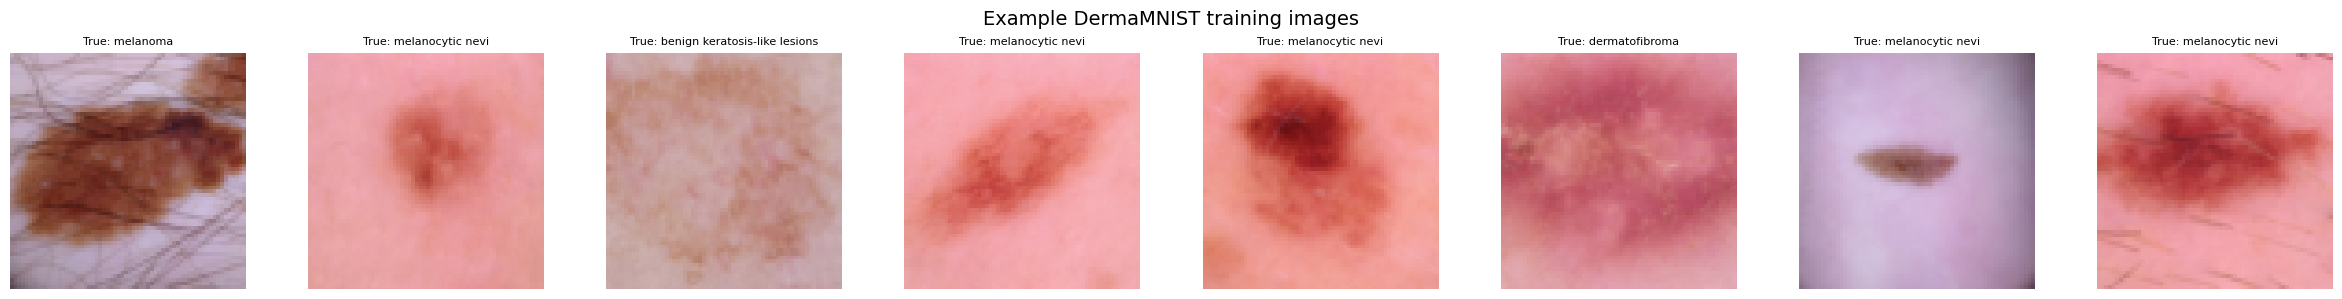

In [52]:
sample_images, sample_labels = next(iter(train_loader))
sample_labels = sample_labels.squeeze().long()

plot_image_grid(
    sample_images,
    labels=sample_labels,
    n=8,
    title="Example DermaMNIST training images",
)

# Model Training

We use a **ResNet-18** model.

ResNet-18 was originally designed for natural images, but we adapt the final classification layer so that it predicts the seven DermaMNIST classes.

The training cell can either:

* load an already saved model from disk, or
* train a new model if no saved model is found.

In [53]:
learning_rate = 0.001
num_epochs = 5
best_model_path = Path("best_dermamnist_resnet_model.pth")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(model.fc)

Linear(in_features=512, out_features=7, bias=True)


## Train or Load the Classifier

If `best_dermamnist_resnet_model.pth` is already available, the notebook loads it.

If the file is not available, the notebook trains the model and saves the best validation checkpoint.

This way the explainability sections always use the same trained classifier.

In [54]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(train_loader.dataset)


def evaluate_accuracy(model, data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    return correct / total


if best_model_path.exists():
    print(f"Loading saved model from: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model = model.to(device)
else:
    print("No saved model found. Training a new model...")
    best_val_acc = 0.0

    for epoch in tqdm.tqdm(range(num_epochs)):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc = evaluate_accuracy(model, val_loader)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"validation accuracy: {100 * val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(
                f"New best model saved with validation accuracy: {100 * best_val_acc:.2f}%"
            )

    model.load_state_dict(torch.load(best_model_path, map_location=device))

model.eval()
print("Model ready.")

Loading saved model from: best_dermamnist_resnet_model.pth
Model ready.


## Validation

Now we check whether the model produces reasonable predictions on the validation set.

This is not the main focus of the notebook, but it is important for XAI:

> Explanations are only meaningful if we know what prediction is being explained.

Accuracy on this validation batch: 88.28%


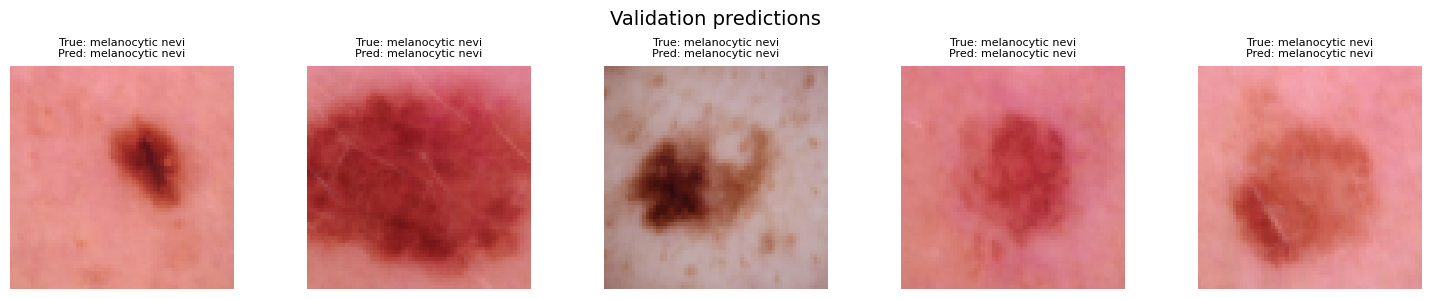

In [55]:
val_images, val_labels = next(iter(val_loader))
val_labels = val_labels.squeeze().long()

val_probs = predict_proba_from_tensor_batch(model, val_images)
val_predictions = torch.argmax(val_probs, dim=1)

val_batch_acc = (val_predictions == val_labels).float().mean().item()
print(f"Accuracy on this validation batch: {100 * val_batch_acc:.2f}%")

plot_image_grid(
    val_images,
    labels=val_labels,
    predictions=val_predictions,
    n=5,
    title="Validation predictions",
)

## Prediction Scores for One Example

The model outputs one score for each class.  
After applying softmax, these scores become class probabilities.

This plot shows how confident the model is for one selected image.

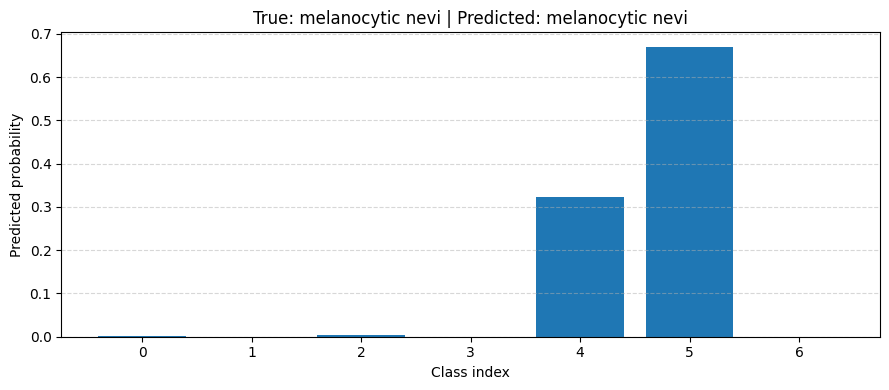

0: actinic keratoses and intraepithelial carcinoma -> 0.001
1: basal cell carcinoma -> 0.000
2: benign keratosis-like lesions -> 0.005
3: dermatofibroma -> 0.000
4: melanoma -> 0.323
5: melanocytic nevi -> 0.670
6: vascular lesions -> 0.000


In [56]:
sample_idx = 2

sample_probs = val_probs[sample_idx].numpy()
true_class_idx = int(val_labels[sample_idx])
pred_class_idx = int(val_predictions[sample_idx])

plt.figure(figsize=(9, 4))
plt.bar(np.arange(n_classes), sample_probs)
plt.xlabel("Class index")
plt.ylabel("Predicted probability")
plt.title(
    f"True: {class_names[true_class_idx]} | "
    f"Predicted: {class_names[pred_class_idx]}"
)
plt.xticks(np.arange(n_classes), [str(i) for i in range(n_classes)])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

for i, p in enumerate(sample_probs):
    print(f"{i}: {class_names[i]} -> {p:.3f}")

# LIME

**LIME** stands for **Local Interpretable Model-agnostic Explanations**.

The basic idea is:

* Take one image.
* Create many slightly perturbed versions of it.
* Check how the model prediction changes.
* Identify which image regions were most important for the prediction.

For images, LIME usually works with **superpixels**.  
A superpixel is a small visually coherent image region.

## Preparing One Image for LIME

LIME expects the image as a NumPy array in `[H, W, C]` format and in the original image scale.

The model, however, expects normalized PyTorch tensors.

Therefore, we define a small wrapper function that converts LIME's perturbed images back into the format expected by the model.

In [57]:
# Reuse one batch from the test set for all explanation methods
test_images, test_labels = next(iter(test_loader))
test_labels = test_labels.squeeze().long()
test_images = test_images.to(device)

test_probs = predict_proba_from_tensor_batch(model, test_images)
test_predictions = torch.argmax(test_probs, dim=1)

print("Test batch loaded once and reused for LIME, Grad-CAM, and SHAP.")
print(f"Batch shape: {test_images.shape}")

Test batch loaded once and reused for LIME, Grad-CAM, and SHAP.
Batch shape: torch.Size([128, 3, 64, 64])


In [58]:
def batch_predict_numpy(images_numpy):
    """
    Prediction function used by LIME and SHAP.

    Input:
        images_numpy: NumPy array [B, H, W, C] in the unnormalized [0, 1] image scale.

    Output:
        class probabilities as NumPy array [B, n_classes].
    """
    model.eval()

    images_tensor = torch.tensor(images_numpy).permute(0, 3, 1, 2).float()
    images_tensor = (images_tensor - mean) / std
    images_tensor = images_tensor.to(device)

    with torch.no_grad():
        logits = model(images_tensor)
        probs = F.softmax(logits, dim=1)

    return probs.detach().cpu().numpy()

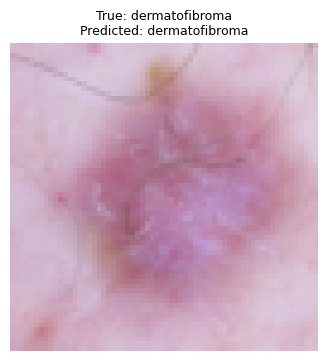

In [59]:
image_idx_to_explain = 1

img_tensor = test_images[image_idx_to_explain].detach().cpu()
img_numpy = tensor_to_numpy_image(img_tensor, mean=mean, std=std)

true_idx = int(test_labels[image_idx_to_explain])
pred_idx = int(test_predictions[image_idx_to_explain])

plt.figure(figsize=(4, 4))
plt.imshow(img_numpy)
plt.title(
    f"True: {class_names[true_idx]}\nPredicted: {class_names[pred_idx]}", fontsize=9
)
plt.axis("off")
plt.show()

## Applying LIME

We use a custom segmentation function because the images are small.

The explanation highlights a few superpixels that support the selected prediction.

In [60]:
segmentation_fn = lambda x: slic(
    x,
    n_segments=30,
    compactness=10,
    sigma=1,
    start_label=1,
)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_numpy,
    batch_predict_numpy,
    top_labels=3,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segmentation_fn,
)

100%|██████████| 1000/1000 [00:02<00:00, 355.19it/s]


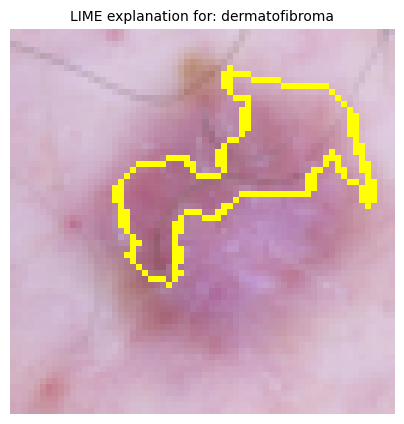

In [61]:
lime_label = explanation.top_labels[0]

temp, mask = explanation.get_image_and_mask(
    lime_label,
    positive_only=True,
    num_features=3,
    hide_rest=False,
)

img_boundary = mark_boundaries(temp, mask)

plt.figure(figsize=(5, 5))
plt.imshow(np.clip(img_boundary, 0, 1))
plt.title(f"LIME explanation for: {class_names[lime_label]}", fontsize=10)
plt.axis("off")
plt.show()

## LIME for Multiple Images

The following helper lets you select several image indices and plot the original image above its LIME explanation. If `target_class_idx=None`, LIME explains the model's predicted class for each image. If you pass a class index, the same target class is explained for every image.

100%|██████████| 500/500 [00:02<00:00, 220.29it/s]


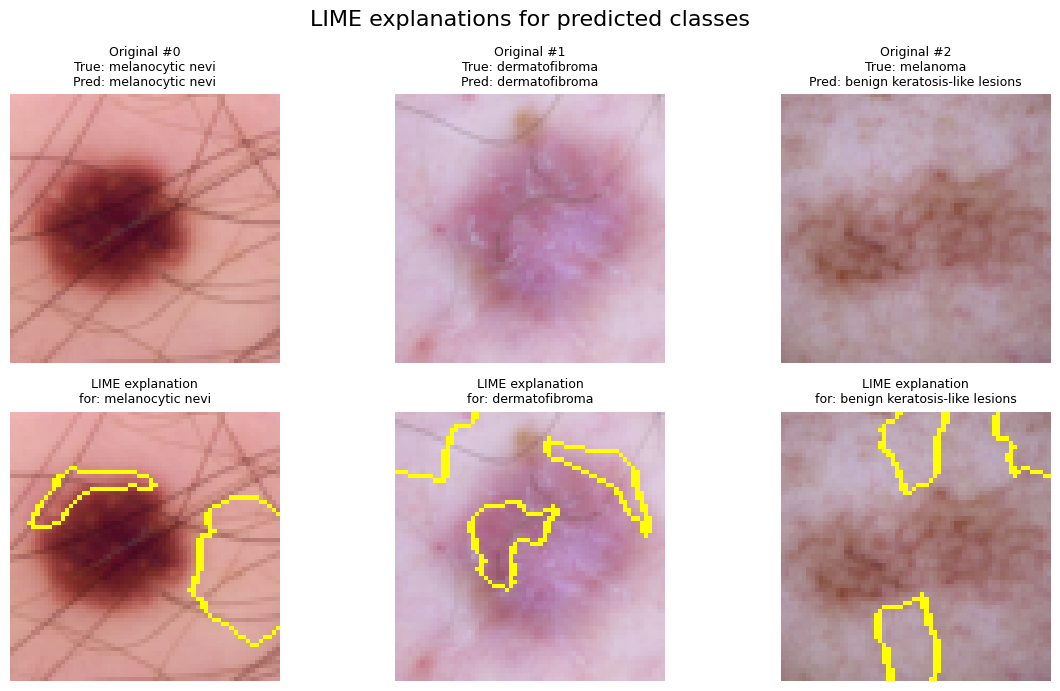

In [62]:
def get_lime_explanation_for_image(
    image_idx,
    target_class_idx=None,
    num_samples=500,
    num_features=3,
):
    """
    Create a LIME explanation for one test image.

    If target_class_idx is None, the model's top predicted class is explained.
    If target_class_idx is given, that selected class is explained for every image.
    """
    img_tensor = test_images[image_idx].detach().cpu()
    img_numpy = tensor_to_numpy_image(img_tensor, mean=mean, std=std)

    if target_class_idx is None:
        explanation = explainer.explain_instance(
            img_numpy,
            batch_predict_numpy,
            top_labels=3,
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=segmentation_fn,
        )
        lime_label = explanation.top_labels[0]
    else:
        explanation = explainer.explain_instance(
            img_numpy,
            batch_predict_numpy,
            labels=(target_class_idx,),
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=segmentation_fn,
        )
        lime_label = target_class_idx

    temp, mask = explanation.get_image_and_mask(
        lime_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False,
    )

    img_boundary = mark_boundaries(temp, mask)

    return img_numpy, img_boundary, lime_label


def plot_lime_multiple_images(
    image_indices,
    target_class_idx=None,
    num_samples=500,
    num_features=3,
):
    """
    First row: original images.
    Second row: LIME explanation overlays.
    """
    n_images = len(image_indices)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=n_images,
        figsize=(4 * n_images, 7),
    )

    if n_images == 1:
        axes = axes.reshape(2, 1)

    for col, image_idx in enumerate(image_indices):
        img_numpy, img_boundary, lime_label = get_lime_explanation_for_image(
            image_idx=image_idx,
            target_class_idx=target_class_idx,
            num_samples=num_samples,
            num_features=num_features,
        )

        true_idx = int(test_labels[image_idx])
        pred_idx = int(test_predictions[image_idx])

        axes[0, col].imshow(img_numpy)
        axes[0, col].set_title(
            f"Original #{image_idx}\n"
            f"True: {class_names[true_idx]}\n"
            f"Pred: {class_names[pred_idx]}",
            fontsize=9,
        )
        axes[0, col].axis("off")

        axes[1, col].imshow(np.clip(img_boundary, 0, 1))
        axes[1, col].set_title(
            f"LIME explanation\nfor: {class_names[lime_label]}",
            fontsize=9,
        )
        axes[1, col].axis("off")

    if target_class_idx is None:
        title = "LIME explanations for predicted classes"
    else:
        title = f"LIME explanations for target class: {class_names[target_class_idx]}"

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


plot_lime_multiple_images(
    image_indices=[0, 1, 2],
    target_class_idx=None,
    num_samples=500,
    num_features=3,
)

### What does the LIME plot show?

The highlighted regions are the superpixels that locally support the selected class prediction.

Important interpretation rule:

> LIME does not prove that these regions are medically causal.  
> It shows which regions were useful for the model in this local prediction.

# Grad-CAM

**Grad-CAM** stands for **Gradient-weighted Class Activation Mapping**.

The idea is to look at the final convolutional feature maps and ask:

> Which spatial regions contributed most to a selected class score?

Grad-CAM produces a heatmap:

* warmer regions = stronger positive contribution
* cooler regions = weaker contribution

## Grad-CAM Heatmap Function

The function below registers hooks on the target convolutional layer.

During the forward pass it stores feature maps.  
During the backward pass it stores gradients.

The gradients tell us how important each feature map is for the selected class.

In [63]:
def make_gradcam_heatmap(model, input_tensor, target_layer, pred_index=None):
    """
    Create a Grad-CAM heatmap for one image.

    The goal is to show which image regions were most important
    for the model's decision for a given class.
    """

    # These lists will store:
    # - the activations from the selected convolutional layer
    # - the gradients of the target class with respect to those activations
    features = []
    gradients = []

    # This hook saves the output of the target convolutional layer
    # during the forward pass.
    def forward_hook(module, input, output):
        features.append(output)

    # This hook saves the gradients flowing back through the target layer
    # during the backward pass.
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Attach the hooks to the chosen convolutional layer.
    # From now on, when this layer is used, we will save its activations and gradients.
    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    # Put the model into evaluation mode.
    # We are not training here, only explaining one prediction.
    model.eval()

    # Forward pass: the image goes through the model.
    # The output contains the class scores.
    output = model(input_tensor)

    # If no target class is specified, explain the class predicted by the model.
    if pred_index is None:
        pred_index = torch.argmax(output, dim=1).item()

    # Clear old gradients before computing new ones.
    model.zero_grad()

    # Select the score of the class we want to explain.
    class_score = output[:, pred_index]

    # Backward pass:
    # compute how much the selected class score depends on the target layer activations.
    class_score.backward()

    # Extract the saved feature maps and gradients.
    # feature_map: activations of the target layer
    # grads: gradients of the target class with respect to those activations
    feature_map = features[0].detach()
    grads = gradients[0].detach()

    # Remove the hooks so they do not keep running in later model calls.
    fwd_handle.remove()
    bwd_handle.remove()

    # Average the gradients over the spatial dimensions.
    # This gives one importance weight per feature-map channel.
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    # Copy the feature maps so we can weight them.
    weighted_feature_map = feature_map.clone()

    # Multiply each feature-map channel by its importance weight.
    # Important channels contribute more to the final heatmap.
    for i in range(weighted_feature_map.shape[1]):
        weighted_feature_map[:, i, :, :] *= pooled_grads[i]

    # Sum across all channels to get one 2D heatmap.
    heatmap = torch.sum(weighted_feature_map, dim=1).squeeze()

    # Keep only positive contributions.
    # These are the regions that support the selected class prediction.
    heatmap = F.relu(heatmap)

    # Normalize the heatmap to the range [0, 1].
    # This makes it easier to visualize.
    if torch.max(heatmap) > 0:
        heatmap = heatmap / torch.max(heatmap)

    return heatmap


def get_resized_gradcam_for_image(model, image, target_layer, target_class_idx=None):
    """
    Create Grad-CAM heatmap for one image and resize it to the original image size.
    """
    img_tensor = image.unsqueeze(0).to(device)

    heatmap = make_gradcam_heatmap(
        model=model,
        input_tensor=img_tensor,
        target_layer=target_layer,
        pred_index=target_class_idx,
    )

    heatmap = heatmap.unsqueeze(0).unsqueeze(0)

    resized_heatmap = F.interpolate(
        heatmap,
        size=(img_tensor.shape[2], img_tensor.shape[3]),
        mode="bilinear",
        align_corners=False,
    )

    return resized_heatmap.squeeze().detach().cpu().numpy()


def plot_single_gradcam(
    model, image, target_layer, target_class_idx=None, title=None, alpha=0.4
):
    """
    Plot one image with a Grad-CAM heatmap overlay.
    """
    original_image = tensor_to_gray_image(image, mean=mean, std=std)
    heatmap = get_resized_gradcam_for_image(
        model=model,
        image=image,
        target_layer=target_layer,
        target_class_idx=target_class_idx,
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(original_image, cmap="gray")
    heatmap_plot = plt.imshow(heatmap, alpha=alpha, cmap="jet")
    plt.colorbar(heatmap_plot, label="Relative Importance")
    plt.title(title if title is not None else "Grad-CAM Heatmap Overlay")
    plt.axis("off")
    plt.show()

## Comparing Non-Melanoma and Melanoma Examples

For a fair visual comparison, we can compute Grad-CAM for the **same target class** across different images.

Here, the target class is automatically set to the melanoma class.

This means:

* for melanoma images, we ask:  
  **Which regions support the melanoma score?**
* for non-melanoma images, we ask:  
  **Which regions would push the model toward melanoma?**

You can also set `target_class_idx=None` if you want each heatmap to explain the model's own predicted class.

In [64]:
import matplotlib as mpl


def find_class_index(class_names, keyword):
    """
    Find a class index by keyword.
    """
    matches = [
        i for i, name in enumerate(class_names) if keyword.lower() in name.lower()
    ]

    if len(matches) == 0:
        raise ValueError(f"No class label contains keyword: {keyword}")

    return matches[0]


def first_k_indices_by_label(labels, label_idx, k=3):
    """
    Return first k indices where the true label equals label_idx.
    """
    idxs = torch.where(labels.cpu() == label_idx)[0].tolist()
    return idxs[:k]


def first_k_indices_excluding_label(labels, label_idx, k=3):
    """
    Return first k indices where the true label is not label_idx.
    """
    idxs = torch.where(labels.cpu() != label_idx)[0].tolist()
    return idxs[:k]


def plot_gradcam_group_comparison(
    model,
    images,
    labels,
    predictions,
    group1_indices,
    group2_indices,
    target_layer,
    target_class_idx=None,
    group1_name="Non-melanoma",
    group2_name="Melanoma",
    heatmap_alpha=0.45,
    heatmap_vmin=0,
    heatmap_vmax=1,
):
    """
    4 x 3 plot:
        row 1: group 1 original grayscale images
        row 2: group 1 grayscale + Grad-CAM overlays
        row 3: group 2 original grayscale images
        row 4: group 2 grayscale + Grad-CAM overlays

    The Grad-CAM color scale is fixed globally from 0 to 1.
    """

    assert len(group1_indices) == 3, "group1_indices must contain exactly 3 indices."
    assert len(group2_indices) == 3, "group2_indices must contain exactly 3 indices."

    model.eval()

    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))

    for col, image_idx in enumerate(group1_indices):
        image = images[image_idx]
        original_gray = tensor_to_gray_image(image, mean=mean, std=std)

        heatmap = get_resized_gradcam_for_image(
            model=model,
            image=image,
            target_layer=target_layer,
            target_class_idx=target_class_idx,
        )

        true_name = class_names[int(labels[image_idx])]
        pred_name = class_names[int(predictions[image_idx])]

        axes[0, col].imshow(original_gray, cmap="gray")
        axes[0, col].set_title(
            f"{group1_name} #{image_idx}\nTrue: {true_name}\nPred: {pred_name}",
            fontsize=8,
        )
        axes[0, col].axis("off")

        axes[1, col].imshow(original_gray, cmap="gray")
        axes[1, col].imshow(
            heatmap,
            alpha=heatmap_alpha,
            cmap="jet",
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
        )
        axes[1, col].set_title(f"{group1_name} Grad-CAM", fontsize=8)
        axes[1, col].axis("off")

    for col, image_idx in enumerate(group2_indices):
        image = images[image_idx]
        original_gray = tensor_to_gray_image(image, mean=mean, std=std)

        heatmap = get_resized_gradcam_for_image(
            model=model,
            image=image,
            target_layer=target_layer,
            target_class_idx=target_class_idx,
        )

        true_name = class_names[int(labels[image_idx])]
        pred_name = class_names[int(predictions[image_idx])]

        axes[2, col].imshow(original_gray, cmap="gray")
        axes[2, col].set_title(
            f"{group2_name} #{image_idx}\nTrue: {true_name}\nPred: {pred_name}",
            fontsize=8,
        )
        axes[2, col].axis("off")

        axes[3, col].imshow(original_gray, cmap="gray")
        axes[3, col].imshow(
            heatmap,
            alpha=heatmap_alpha,
            cmap="jet",
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
        )
        axes[3, col].set_title(f"{group2_name} Grad-CAM", fontsize=8)
        axes[3, col].axis("off")

    if target_class_idx is None:
        main_title = "Grad-CAM comparison: predicted class explained for each image"
    else:
        main_title = (
            f"Grad-CAM comparison for target class: {class_names[target_class_idx]}"
        )

    fig.suptitle(main_title, fontsize=16)

    # Leave space on the right side for the colorbar.
    fig.subplots_adjust(
        left=0.04,
        right=0.86,
        top=0.90,
        bottom=0.04,
        hspace=0.45,
        wspace=0.18,
    )

    # Dedicated colorbar axis outside the image grid.
    cbar_ax = fig.add_axes([0.90, 0.18, 0.025, 0.62])

    norm = mpl.colors.Normalize(vmin=heatmap_vmin, vmax=heatmap_vmax)
    scalar_mappable = mpl.cm.ScalarMappable(cmap="jet", norm=norm)
    scalar_mappable.set_array([])

    fig.colorbar(
        scalar_mappable,
        cax=cbar_ax,
        label="Relative Importance",
    )

    plt.show()

Melanoma class index: 4 -> melanoma


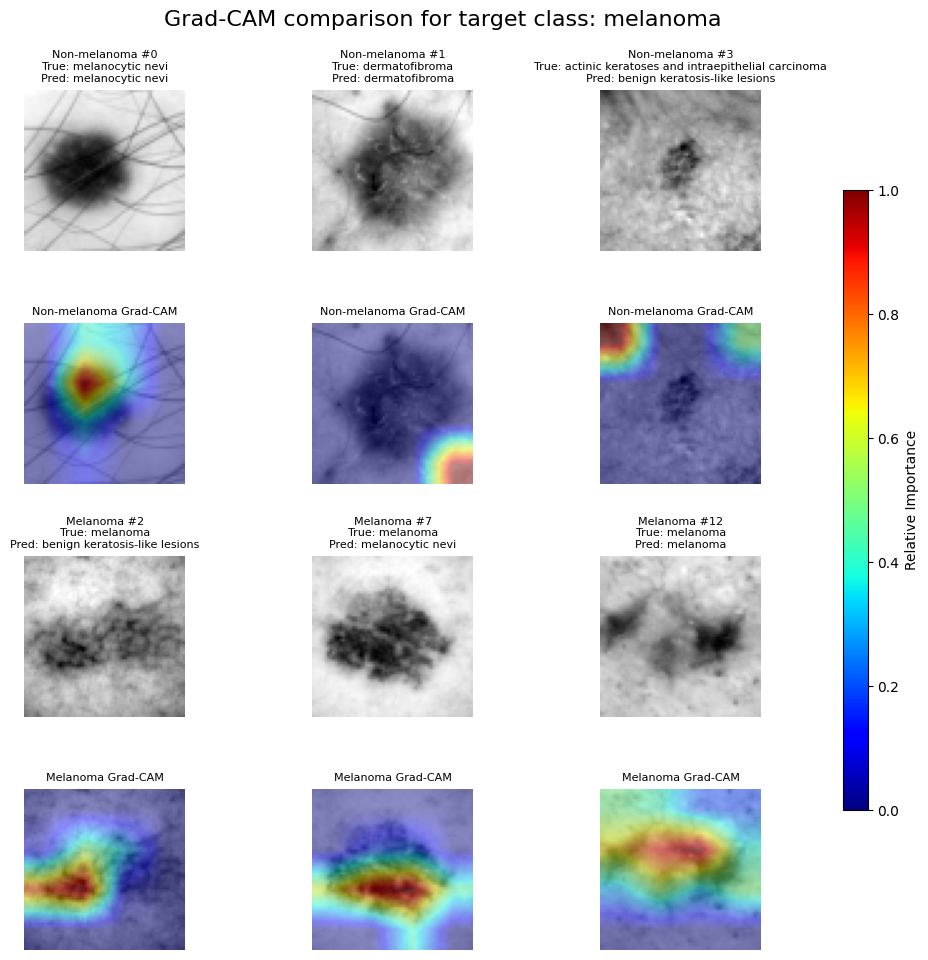

In [65]:
target_layer = model.layer3[-1]

melanoma_class_idx = find_class_index(class_names, "melanoma")
print(
    f"Melanoma class index: {melanoma_class_idx} -> {class_names[melanoma_class_idx]}"
)

# Automatic example selection from the current test batch.
# You can replace these lists with your own image indices.
non_melanoma_indices = first_k_indices_excluding_label(
    test_labels, melanoma_class_idx, k=3
)
melanoma_indices = first_k_indices_by_label(test_labels, melanoma_class_idx, k=3)

plot_gradcam_group_comparison(
    model=model,
    images=test_images,
    labels=test_labels,
    predictions=test_predictions,
    group1_indices=non_melanoma_indices,
    group2_indices=melanoma_indices,
    target_layer=target_layer,
    target_class_idx=melanoma_class_idx,
    group1_name="Non-melanoma",
    group2_name="Melanoma",
)

### How to Interpret the Comparison

The heatmaps are calculated for the **same melanoma target class**.

This makes the comparison easier:

* If a melanoma image has a focused heatmap on the lesion, the model may be using lesion-relevant regions.
* If a non-melanoma image also shows strong melanoma heatmap regions, the model may see melanoma-like visual patterns there.
* If the heatmap is outside the lesion, the model may be relying on irrelevant artifacts.

Important limitation:

> Grad-CAM is a model explanation, not a medical diagnosis.

## Grad-CAM for Multiple Target Classes of the Same Image

One image is shown once, then Grad-CAM is computed for several target classes.

In [66]:
def get_top_k_predicted_class_indices(model, image, k=5):
    """
    Return the top-k predicted class indices and probabilities for one image.
    image shape: [C, H, W]
    """
    device = next(model.parameters()).device
    model.eval()

    img_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1).squeeze()

    top_probs, top_indices = torch.topk(probs, k=k)
    print("Class probabilities:")
    for i, prob in enumerate(probs):
        print(f"{i}: {class_names[i]} | probability = {prob.item():.4f}")

    return top_indices.detach().cpu().tolist(), top_probs.detach().cpu().tolist()


def wrap_class_name(class_name, width=18):
    """
    Break long class names into multiple lines for cleaner plot titles.
    """
    return "\n".join(textwrap.wrap(class_name, width=width))


def plot_gradcam_for_multiple_classes(
    model,
    image,
    target_layer,
    class_indices,
    class_names,
    true_label=None,
    predicted_label=None,
    mean=None,
    std=None,
    heatmap_alpha=0.45,
    use_local_color_scale=False,
    heatmap_vmin=0,
    heatmap_vmax=1,
    figsize=None,
):
    """
    Plot one image and Grad-CAM explanations for several target classes.

    Layout:
        column 1: original grayscale image
        remaining columns: Grad-CAM overlay for selected target classes

    A single shared colorbar is shown on the right.
    """

    model.eval()

    n_classes = len(class_indices)
    n_cols = n_classes + 1

    if figsize is None:
        figsize = (3.3 * n_cols, 4.2)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_cols,
        figsize=figsize,
    )

    if n_cols == 1:
        axes = [axes]

    original_gray = tensor_to_gray_image(
        image,
        mean=mean,
        std=std,
    )

    # -------------------------
    # Original image
    # -------------------------
    axes[0].imshow(original_gray, cmap="gray")

    original_title = "Original image"
    if true_label is not None and predicted_label is not None:
        original_title += (
            f"\nTrue: {wrap_class_name(class_names[int(true_label)], width=16)}"
            f"\nPred: {wrap_class_name(class_names[int(predicted_label)], width=16)}"
        )

    axes[0].set_title(original_title, fontsize=9)
    axes[0].axis("off")

    # -------------------------
    # Grad-CAM for each target class
    # -------------------------
    for col, class_idx in enumerate(class_indices, start=1):
        heatmap = get_resized_gradcam_for_image(
            model=model,
            image=image,
            target_layer=target_layer,
            target_class_idx=class_idx,
        )

        axes[col].imshow(original_gray, cmap="gray")

        if use_local_color_scale:
            current_vmin = float(heatmap.min())
            current_vmax = float(heatmap.max())

            if current_vmax == current_vmin:
                current_vmin = 0
                current_vmax = 1
        else:
            current_vmin = heatmap_vmin
            current_vmax = heatmap_vmax

        axes[col].imshow(
            heatmap,
            alpha=heatmap_alpha,
            cmap="jet",
            vmin=current_vmin,
            vmax=current_vmax,
        )

        axes[col].set_title(
            f"Grad-CAM\n{wrap_class_name(class_names[class_idx], width=18)}",
            fontsize=9,
        )
        axes[col].axis("off")

    # -------------------------
    # Shared colorbar
    # -------------------------
    if use_local_color_scale:
        # Shared colorbar only really makes sense with global scale.
        # But if local scale is requested, show a generic 0-1 bar.
        norm = mpl.colors.Normalize(vmin=0, vmax=1)
    else:
        norm = mpl.colors.Normalize(vmin=heatmap_vmin, vmax=heatmap_vmax)

    scalar_mappable = mpl.cm.ScalarMappable(
        cmap="jet",
        norm=norm,
    )
    scalar_mappable.set_array([])

    fig.subplots_adjust(
        left=0.03,
        right=0.92,
        top=0.82,
        bottom=0.10,
        wspace=0.12,
    )

    cbar_ax = fig.add_axes([0.94, 0.18, 0.01, 0.56])

    fig.colorbar(
        scalar_mappable,
        cax=cbar_ax,
        label="Relative Importance",
    )

    plt.suptitle(
        "Grad-CAM explanations for multiple target classes",
        fontsize=15,
        y=0.96,
    )

    plt.show()

Class probabilities:
0: actinic keratoses and intraepithelial carcinoma | probability = 0.0025
1: basal cell carcinoma | probability = 0.0165
2: benign keratosis-like lesions | probability = 0.0026
3: dermatofibroma | probability = 0.9629
4: melanoma | probability = 0.0014
5: melanocytic nevi | probability = 0.0127
6: vascular lesions | probability = 0.0014


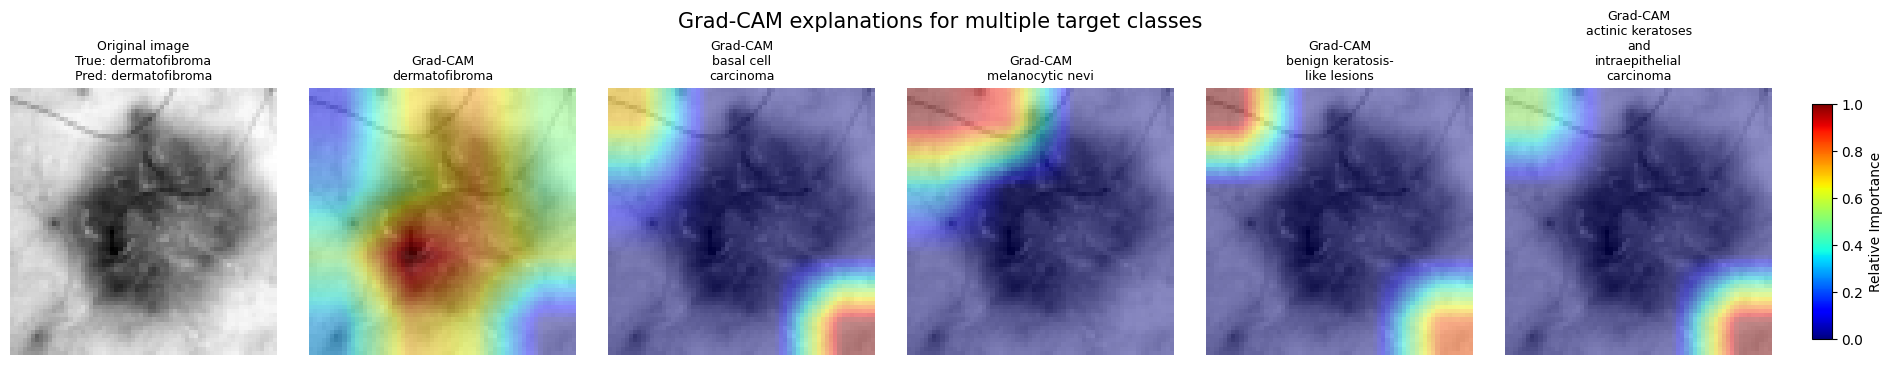

In [67]:
image_idx_to_explain = 1
image = test_images[image_idx_to_explain]

true_idx = int(test_labels[image_idx_to_explain])
pred_idx = int(test_predictions[image_idx_to_explain])

top_class_indices, top_class_probs = get_top_k_predicted_class_indices(
    model=model,
    image=image,
    k=5,
)

plot_gradcam_for_multiple_classes(
    model=model,
    image=image,
    target_layer=target_layer,
    class_indices=top_class_indices,
    class_names=class_names,
    true_label=true_idx,
    predicted_label=pred_idx,
    mean=mean,
    std=std,
    heatmap_alpha=0.45,
    use_local_color_scale=False,  # fontos
    heatmap_vmin=0,
    heatmap_vmax=1,
)

# SHAP

**SHAP** stands for **SHapley Additive exPlanations**.

The intuition comes from game theory:

> A prediction is treated like a payout, and each image region is treated like a player that contributes to that payout.

For images, SHAP estimates how much different regions of the image support or oppose selected class predictions.

## Preparing One Image for SHAP

SHAP also uses the same prediction wrapper as LIME.

The selected image is provided as an unnormalized NumPy array in `[B, H, W, C]` format.

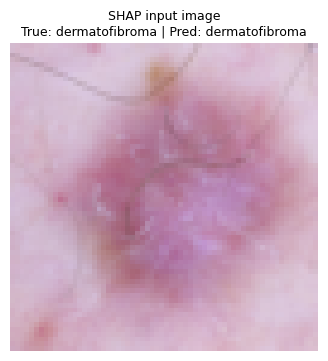

In [68]:
img_tensor_norm = test_images[image_idx_to_explain].unsqueeze(0)
img_numpy_unnorm = (
    img_tensor_norm.detach().cpu().permute(0, 2, 3, 1).numpy() * std + mean
)
img_numpy_unnorm = np.clip(img_numpy_unnorm, 0, 1)

true_idx = int(test_labels[image_idx_to_explain])
pred_idx = int(test_predictions[image_idx_to_explain])

plt.figure(figsize=(4, 4))
plt.imshow(img_numpy_unnorm[0])
plt.title(
    f"SHAP input image\nTrue: {class_names[true_idx]} | Pred: {class_names[pred_idx]}",
    fontsize=9,
)
plt.axis("off")
plt.show()

## Applying SHAP

* SHAP estimates how much each image region contributes to the model prediction.
* It hides or perturbs parts of the image and checks how the prediction changes.
* Hidden regions are replaced by a blurred image using `"blur(16, 16)"`.
* Regions that strongly change the prediction receive higher SHAP importance.
* Positive SHAP values support the selected class prediction.
* Negative SHAP values push the prediction away from that class.


In [69]:
# Line-wrapped class names for cleaner SHAP panel titles.
shap_class_names = [wrap_class_name(name, width=24) for name in class_names]

mask_value = "blur(16, 16)"

masker = shap.maskers.Image(mask_value, img_numpy_unnorm[0].shape)

shap_explainer = shap.Explainer(
    batch_predict_numpy,
    masker,
    output_names=shap_class_names,
)

shap_values = shap_explainer(
    img_numpy_unnorm,
    max_evals=500,
    batch_size=50,
    outputs=shap.Explanation.argsort.flip[:5],
)

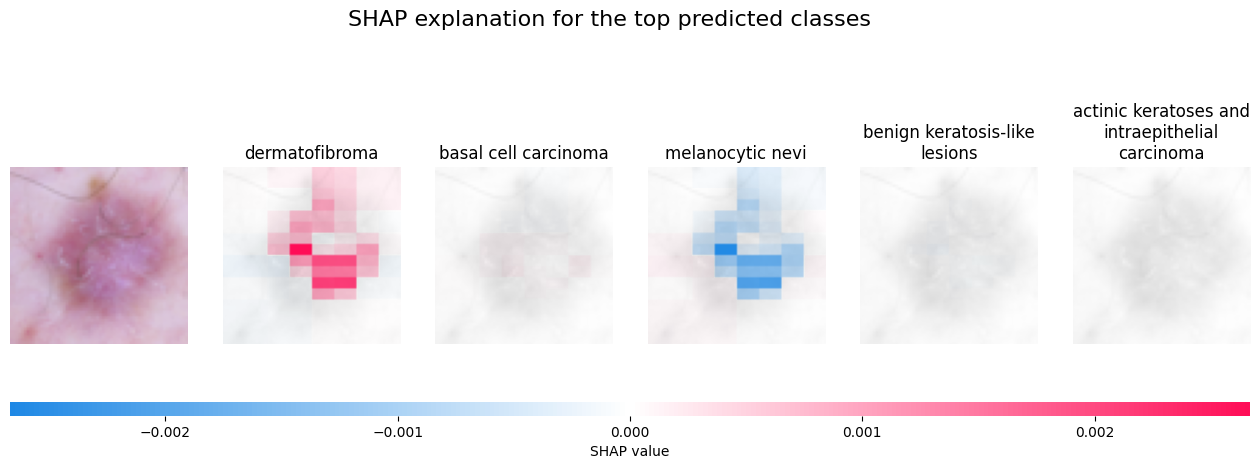

In [70]:
shap.image_plot(
    shap_values,
    width=18,
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(16, 5)

plt.suptitle(
    "SHAP explanation for the top predicted classes",
    fontsize=16,
    y=1.01,
)
plt.show()

# Summary

In this notebook, we used one common DermaMNIST workflow and reused the same loaded data and trained model for all explanation methods.

The three XAI methods answer related but slightly different questions:

| Method | Main question | Output |
|---|---|---|
| LIME | Which local superpixels support the prediction? | highlighted image regions |
| Grad-CAM | Which spatial regions activate the selected class? | heatmap overlay |
| SHAP | How do image regions contribute to class probabilities? | positive and negative contribution map |

The key interpretation rule is the same for all three:

> These methods explain the model's behavior.  
> They do not prove biological or clinical causality.